# <font color='green'> <center> **Projet Epidémiologie Cabanes / Dechenais** </center>

## **Chargement des données :**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer

%matplotlib inline

df_h1 = pd.read_csv('liver.csv')
df_h2 = pd.read_json('liver.json')


In [2]:
df_h1

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,41 to 60 yo,Male,7.0,2.0,174.0,NaN,14,7800.0 mg/dL,4.2,NaN,2
1,41 to 60 yo,Male,6.0,2.0,245.0,22.0,24,7100.0 mg/dL,3.4,0.9,1
2,21 to 40 yo,Male,11.0,5.0,191.0,37.0,41,7700.0 mg/dL,4.3,NaN,2
3,21 to 40 yo,Male,24.0,10.0,340.0,25.0,21,8300.0 mg/dL,4.5,NaN,1
4,21 to 40 yo,Male,6.0,2.0,202.0,NaN,41,8000.0 mg/dL,3.9,0.9,1
...,...,...,...,...,...,...,...,...,...,...,...
316,<20 yo,Male,14.0,5.0,269.0,58.0,45,6700.0 mg/dL,3.9,1.4,1
317,61 to 80 yo,Male,7.0,1.0,196.0,20.0,35,5800.0 mg/dL,2.0,0.5,1
318,61 to 80 yo,Male,28.0,13.0,250.0,NaN,29,2700.0 mg/dL,0.9,0.5,1
319,41 to 60 yo,Male,9.0,3.0,901.0,23.0,17,6200.0 mg/dL,3.5,1.2,1


In [3]:
df_h2

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,61 to 80 yo,Female,0.7,0.1,187.0,NaN,18,6.8,3.3,0.90,1
1,61 to 80 yo,Male,10.9,5.5,699.0,64.0,100,7.5,NaN,0.74,1
2,61 to 80 yo,Male,7.3,4.1,490.0,NaN,68,7.0,3.3,NaN,1
3,41 to 60 yo,Male,1.0,0.4,182.0,14.0,20,6.8,3.4,1.00,1
4,61 to 80 yo,Male,3.9,2.0,195.0,27.0,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
286,21 to 40 yo,Female,0.8,0.2,192.0,15.0,12,8.6,4.7,1.20,1
287,41 to 60 yo,Male,1.3,0.6,155.0,15.0,20,8.0,4.0,1.00,2
288,41 to 60 yo,Female,1.0,0.5,239.0,16.0,39,7.5,3.7,NaN,1
289,41 to 60 yo,Male,4.5,2.3,315.0,120.0,105,7.0,4.0,NaN,1


## **Analyse des jeux de données :**

In [4]:
print(df_h1.info())
df_h2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         321 non-null    object 
 1   Gender                      321 non-null    object 
 2   Total_Bilirubin             317 non-null    float64
 3   Direct_Bilirubin            320 non-null    float64
 4   Alkaline_Phosphotase        317 non-null    float64
 5   ALT                         254 non-null    float64
 6   AST                         321 non-null    int64  
 7   Total_Proteins              321 non-null    object 
 8   Albumin                     316 non-null    float64
 9   Albumin_and_Globulin_Ratio  262 non-null    float64
 10  Result                      321 non-null    int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 27.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (

#### **Remarque :**

- Total_Proteins est de type objet dans le df_h1 et de type float64 dans le df_h2

- ALT, ASP et Result de df_h1 sont appelés Alamine_Aminotransferase, Aspartate_Aminotransferase et Outcome dans df_h2

## **Visualisation graphique :**

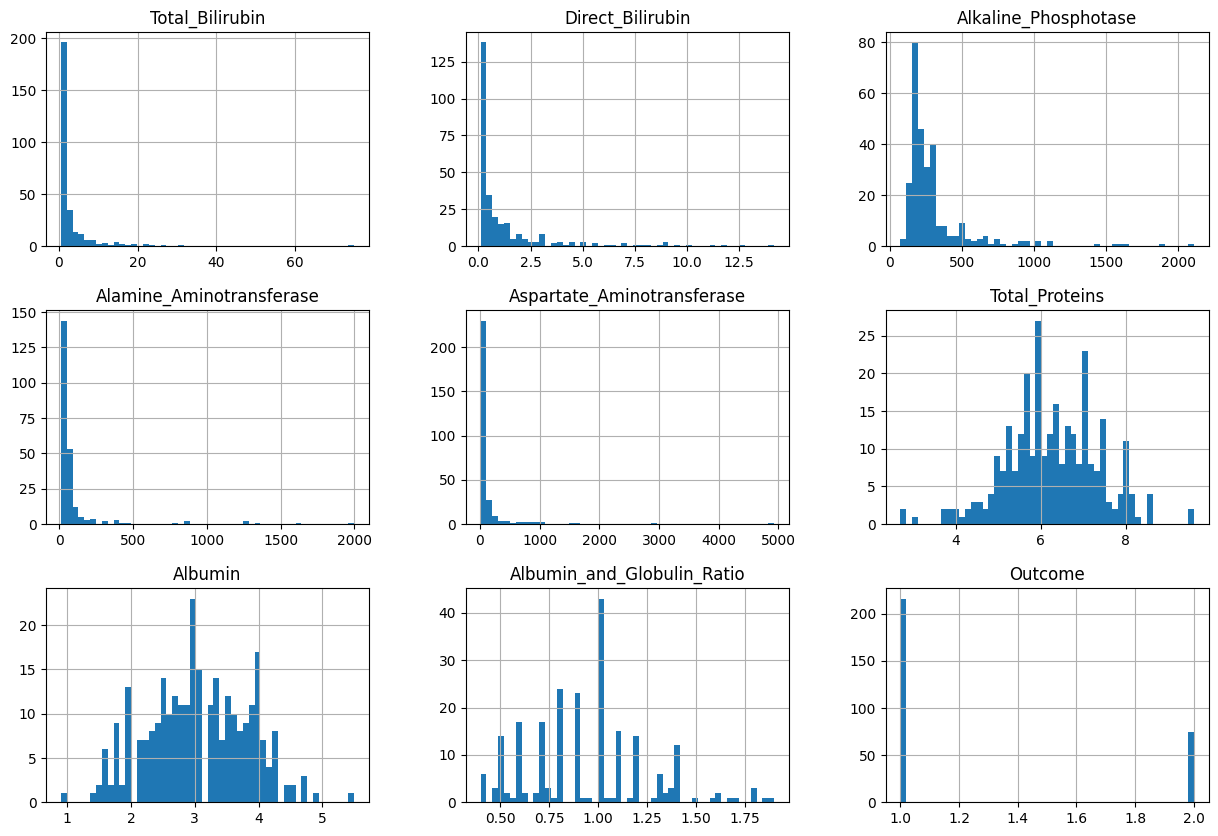

In [5]:
df_h2.hist(bins=50, figsize=(15, 10))
plt.show()

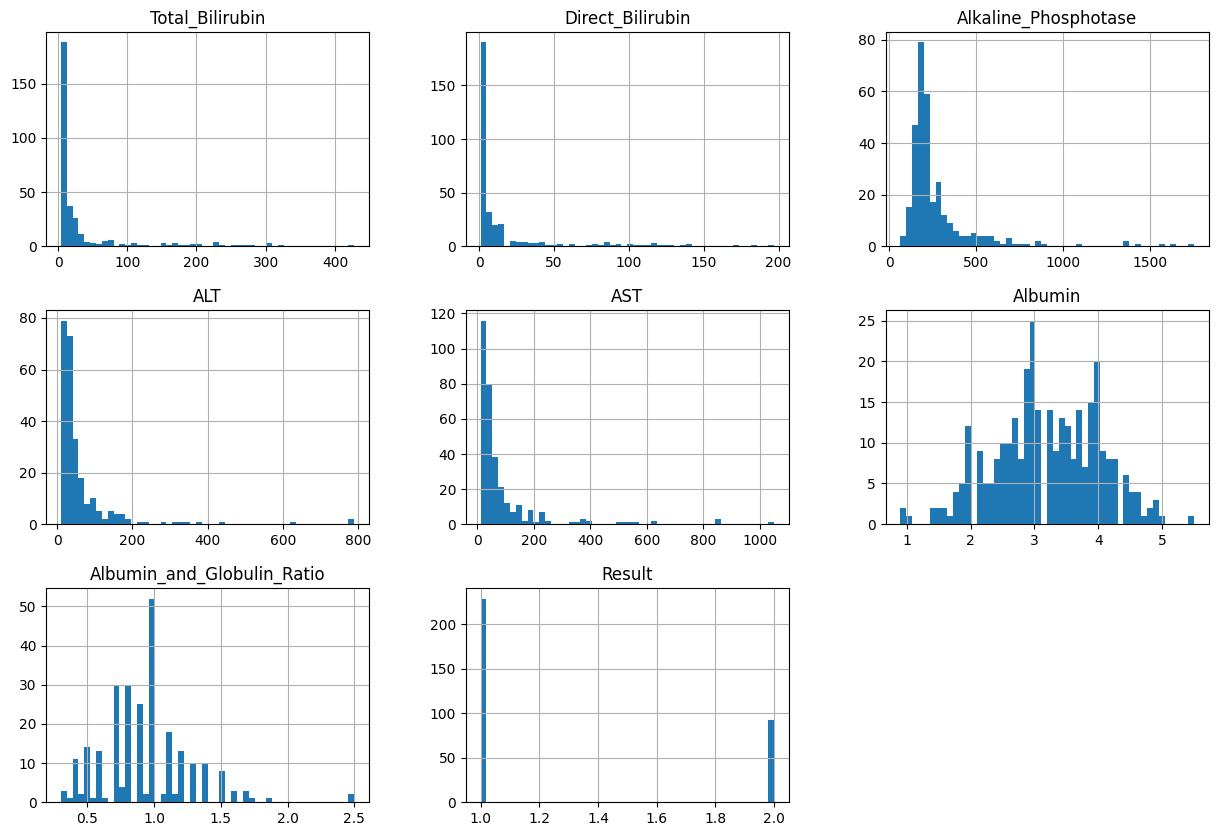

In [6]:
df_h1.hist(bins=50, figsize=(15, 10))
plt.show()

## **Harmonisation de l'unité de la colonne Total_Proteins :**

In [7]:
def check_protein_format(protein_str, unite):
    return isinstance(protein_str, str) and protein_str.endswith(unite)

def extract_protein_value(protein_str):
    if check_protein_format(protein_str, 'mg/dL'):
        protein_float = float(str.split(protein_str, ' ')[0])
        return protein_float /1000
    if check_protein_format(protein_str, 'g/dL'):
        protein_float = float(str.split(protein_str, ' ')[0])
        return protein_float * 1000 / 1000
    if check_protein_format(protein_str, 'nan mg/dL'):
        return np.nan

df_h1['Total_Proteins'] = df_h1['Total_Proteins'].apply(extract_protein_value)
df_h1.head(3)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,41 to 60 yo,Male,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2
1,41 to 60 yo,Male,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1
2,21 to 40 yo,Male,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2


## **Harmonisation de l'unité de Total_Bilirubin, Direct_Bilirubin :**

In [8]:
def harmonize_Total_Bilirubin(df):
    df['Total_Bilirubin'] = df['Total_Bilirubin']*10
    return df

df_h2 = harmonize_Total_Bilirubin(df_h2)
df_h2.head(3)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,61 to 80 yo,Female,7.0,0.1,187.0,NaN,18,6.8,3.3,0.90,1
1,61 to 80 yo,Male,109.0,5.5,699.0,64.0,100,7.5,NaN,0.74,1
2,61 to 80 yo,Male,73.0,4.1,490.0,NaN,68,7.0,3.3,NaN,1


In [9]:
def harmonize_Direct_Bilirubin(df):
    df['Direct_Bilirubin'] = df['Direct_Bilirubin']*10
    return df

df_h2 = harmonize_Direct_Bilirubin(df_h2)
df_h2.head(3)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,61 to 80 yo,Female,7.0,1.0,187.0,NaN,18,6.8,3.3,0.90,1
1,61 to 80 yo,Male,109.0,55.0,699.0,64.0,100,7.5,NaN,0.74,1
2,61 to 80 yo,Male,73.0,41.0,490.0,NaN,68,7.0,3.3,NaN,1


## **Renommer les colonnes du jeu de données df_h1 :**

In [10]:
df_h1.rename(columns={'Age': 'Age'
                    , 'Gender': 'Gender'
                    , 'Total_Bilirubin': 'Total_Bilirubin'
                    , 'Direct_Bilirubin': 'Direct_Bilirubin'
                    , 'Alkaline_Phosphotase': 'Alkaline_Phosphotase'
                    , 'ALT': 'Alamine_Aminotransferase'
                    , 'AST': 'Aspartate_Aminotransferase'
                    , 'Total_Protiens': 'Total_Protiens'
                    , 'Albumin': 'Albumin'
                    , 'Albumin_and_Globulin_Ratio': 'Albumin_and_Globulin_Ratio'
                    ,'Result': 'Outcome'
                     }, inplace=True)


df_h1.head(3)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,41 to 60 yo,Male,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2
1,41 to 60 yo,Male,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1
2,21 to 40 yo,Male,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2


## **Concaténation des jeux de données :**

In [11]:
df_combined = pd.concat([df_h1, df_h2])
df_combined

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,41 to 60 yo,Male,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2
1,41 to 60 yo,Male,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1
2,21 to 40 yo,Male,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2
3,21 to 40 yo,Male,24.0,10.0,340.0,25.0,21,8.3,4.5,NaN,1
4,21 to 40 yo,Male,6.0,2.0,202.0,NaN,41,8.0,3.9,0.9,1
...,...,...,...,...,...,...,...,...,...,...,...
286,21 to 40 yo,Female,8.0,2.0,192.0,15.0,12,8.6,4.7,1.2,1
287,41 to 60 yo,Male,13.0,6.0,155.0,15.0,20,8.0,4.0,1.0,2
288,41 to 60 yo,Female,10.0,5.0,239.0,16.0,39,7.5,3.7,NaN,1
289,41 to 60 yo,Male,45.0,23.0,315.0,120.0,105,7.0,4.0,NaN,1


## **Retirer les doublons :**

In [12]:
df_combined.drop_duplicates(inplace=True)
df_combined

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome
0,41 to 60 yo,Male,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2
1,41 to 60 yo,Male,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1
2,21 to 40 yo,Male,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2
3,21 to 40 yo,Male,24.0,10.0,340.0,25.0,21,8.3,4.5,NaN,1
4,21 to 40 yo,Male,6.0,2.0,202.0,NaN,41,8.0,3.9,0.9,1
...,...,...,...,...,...,...,...,...,...,...,...
286,21 to 40 yo,Female,8.0,2.0,192.0,15.0,12,8.6,4.7,1.2,1
287,41 to 60 yo,Male,13.0,6.0,155.0,15.0,20,8.0,4.0,1.0,2
288,41 to 60 yo,Female,10.0,5.0,239.0,16.0,39,7.5,3.7,NaN,1
289,41 to 60 yo,Male,45.0,23.0,315.0,120.0,105,7.0,4.0,NaN,1


## **Visualiser la distribution des données :**

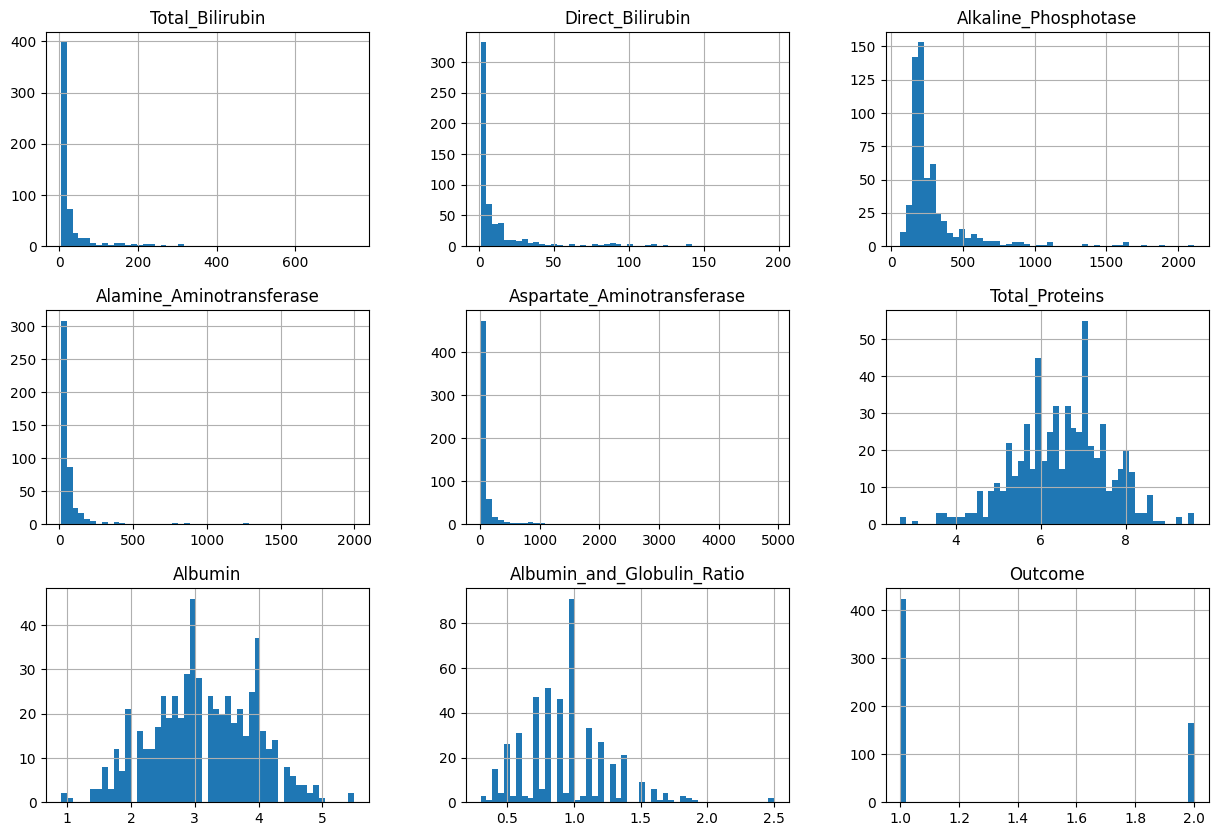

In [13]:
hist_df_combined = df_combined.hist(bins=50, figsize=(15, 10))

## **Gestion des Variables Catégorielles (OneHotEncoding, puis LabelEncoding) :**

j'ai utilisé ce site pour mettre 1 et 0 au lieu de True et False

https://stackoverflow.com/questions/77643432/why-is-pd-get-dummies-returning-boolean-values-instead-of-the-binaries-of-0-1


In [14]:
df_encoded = pd.get_dummies(data = df_combined, columns=['Gender'], dtype=int) 
df_encoded

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,41 to 60 yo,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2,0,1
1,41 to 60 yo,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1,0,1
2,21 to 40 yo,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2,0,1
3,21 to 40 yo,24.0,10.0,340.0,25.0,21,8.3,4.5,NaN,1,0,1
4,21 to 40 yo,6.0,2.0,202.0,NaN,41,8.0,3.9,0.9,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
286,21 to 40 yo,8.0,2.0,192.0,15.0,12,8.6,4.7,1.2,1,1,0
287,41 to 60 yo,13.0,6.0,155.0,15.0,20,8.0,4.0,1.0,2,0,1
288,41 to 60 yo,10.0,5.0,239.0,16.0,39,7.5,3.7,NaN,1,1,0
289,41 to 60 yo,45.0,23.0,315.0,120.0,105,7.0,4.0,NaN,1,0,1


In [15]:
#LabelEncoder les tris par ordre alphabétique et non pas dans l'ordre que l'on veut. 
# On a donc créee une fonction pour le faire manuellement.
d = {'<20 yo': 0, '21 to 40 yo': 1, '41 to 60 yo': 2, '61 to 80 yo': 3, '>80 yo': 4}
def LabelEncoder2(val):
    return d[val]

df_encoded_2 = df_encoded.copy()
df_encoded_2['Age'] = df_encoded_2['Age'].apply(LabelEncoder2)

df_encoded_2

# 0 pour <20 yo, 1 pour 21-40 yo, 2 pour 41-60 yo, 3 pour 61-80 yo, 4 pour >80 yo

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,2,7.0,2.0,174.0,NaN,14,7.8,4.2,NaN,2,0,1
1,2,6.0,2.0,245.0,22.0,24,7.1,3.4,0.9,1,0,1
2,1,11.0,5.0,191.0,37.0,41,7.7,4.3,NaN,2,0,1
3,1,24.0,10.0,340.0,25.0,21,8.3,4.5,NaN,1,0,1
4,1,6.0,2.0,202.0,NaN,41,8.0,3.9,0.9,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
286,1,8.0,2.0,192.0,15.0,12,8.6,4.7,1.2,1,1,0
287,2,13.0,6.0,155.0,15.0,20,8.0,4.0,1.0,2,0,1
288,2,10.0,5.0,239.0,16.0,39,7.5,3.7,NaN,1,1,0
289,2,45.0,23.0,315.0,120.0,105,7.0,4.0,NaN,1,0,1


## **Complétion des valeurs manquantes :**

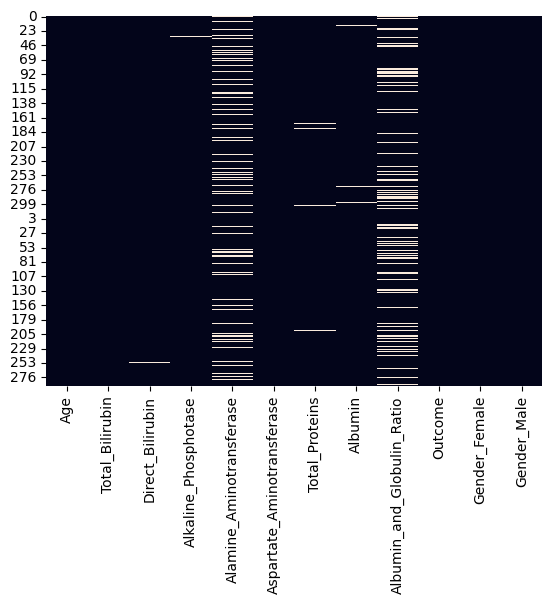

In [16]:
# Afficher un aperçu des valeurs manquantes (méthode isna())
import seaborn

na_columns = df_encoded_2.columns[df_encoded_2.isna().any()].tolist()
na_columns2 = seaborn.heatmap(df_encoded_2.isna(), cbar=False)

## **Imputation des valeurs par méthode K-Nearest Neighbour (KNN) :**

In [17]:
def data_imputation(df, cols = []):
    int_columns = df.select_dtypes(include='int').columns.tolist()
    imputer = KNNImputer(n_neighbors=5)
    df_imputed = df.copy()

    df_imputed[cols] = imputer.fit_transform(df_imputed[cols])

    df_imputed[int_columns] = df_imputed[int_columns].round(0).astype(int)

    return df_imputed

df_imputed = data_imputation(df_encoded_2, na_columns)

df_imputed

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,2,7.0,2.0,174.0,43.0,14,7.8,4.2,1.180,2,0,1
1,2,6.0,2.0,245.0,22.0,24,7.1,3.4,0.900,1,0,1
2,1,11.0,5.0,191.0,37.0,41,7.7,4.3,1.360,2,0,1
3,1,24.0,10.0,340.0,25.0,21,8.3,4.5,0.940,1,0,1
4,1,6.0,2.0,202.0,32.4,41,8.0,3.9,0.900,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
286,1,8.0,2.0,192.0,15.0,12,8.6,4.7,1.200,1,1,0
287,2,13.0,6.0,155.0,15.0,20,8.0,4.0,1.000,2,0,1
288,2,10.0,5.0,239.0,16.0,39,7.5,3.7,0.842,1,1,0
289,2,45.0,23.0,315.0,120.0,105,7.0,4.0,0.874,1,0,1


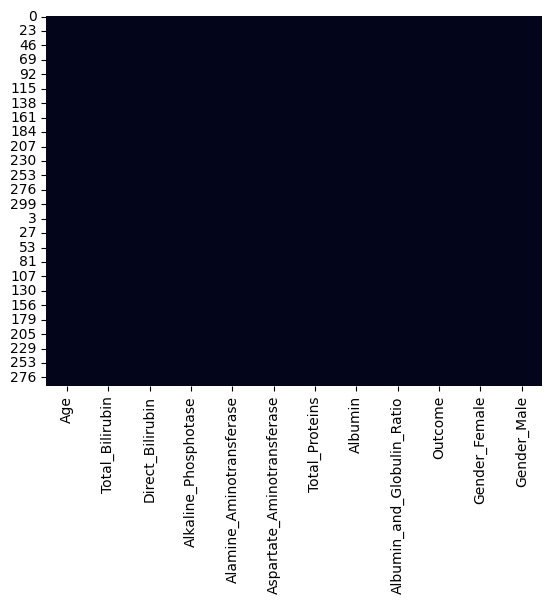

In [18]:
na_columns = df_imputed.columns[df_imputed.isna().any()].tolist()
na_columns2 = seaborn.heatmap(df_imputed.isna(), cbar=False)

## **Qualité des données après complétion des données manquantes :**

In [19]:
def compare_stats(df1, df2):
    diff = pd.DataFrame(index=df1.columns, columns=['Diff_Moyenne', 'Diff_Std'])
    
    diff['Diff_Moyenne'] = ((df2.mean() - df1.mean()) / df1.mean()).abs()
    diff['Diff_Std'] = ((df2.std() - df1.std()) / df1.std()).abs()
    
    return diff

df_stats_comp_after_completion = compare_stats(df_encoded_2, df_imputed)


df_stats_comp_after_completion

,Diff_Moyenne,Diff_Std
Age,0.000000,0.000000
Total_Bilirubin,0.004834,0.003823
Direct_Bilirubin,0.000116,0.003307
Alkaline_Phosphotase,0.002362,0.003668
Alamine_Aminotransferase,0.035629,0.090717
Aspartate_Aminotransferase,0.000000,0.000000
Total_Proteins,0.000270,0.003566
Albumin,0.000805,0.001929
Albumin_and_Globulin_Ratio,0.000981,0.079976
Outcome,0.000000,0.000000


## **Biais d'outlier et détection des valeurs aberrantes :**

In [20]:
def detect_outliers(df, num_std=2, threshold=1):
    df_outliers = df.copy()
    means = df_outliers.mean()
    stds = df_outliers.std()
    df_outliers['Outlier_Count'] = ((df_outliers - means).abs() > num_std * stds).sum(axis=1)

    return df_outliers


def remove_outliers(df, threshold):
    df_with_outliers = detect_outliers(df)
    df_without_outliers = df_with_outliers[df_with_outliers['Outlier_Count'] <= threshold].drop(columns='Outlier_Count')
    return df_without_outliers


df_outliers = remove_outliers(df_imputed,2)

df_outliers

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,2,7.0,2.0,174.0,43.0,14,7.8,4.2,1.180,2,0,1
1,2,6.0,2.0,245.0,22.0,24,7.1,3.4,0.900,1,0,1
2,1,11.0,5.0,191.0,37.0,41,7.7,4.3,1.360,2,0,1
3,1,24.0,10.0,340.0,25.0,21,8.3,4.5,0.940,1,0,1
4,1,6.0,2.0,202.0,32.4,41,8.0,3.9,0.900,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
286,1,8.0,2.0,192.0,15.0,12,8.6,4.7,1.200,1,1,0
287,2,13.0,6.0,155.0,15.0,20,8.0,4.0,1.000,2,0,1
288,2,10.0,5.0,239.0,16.0,39,7.5,3.7,0.842,1,1,0
289,2,45.0,23.0,315.0,120.0,105,7.0,4.0,0.874,1,0,1


## **Gestion du Déséquilibre de Classe :**

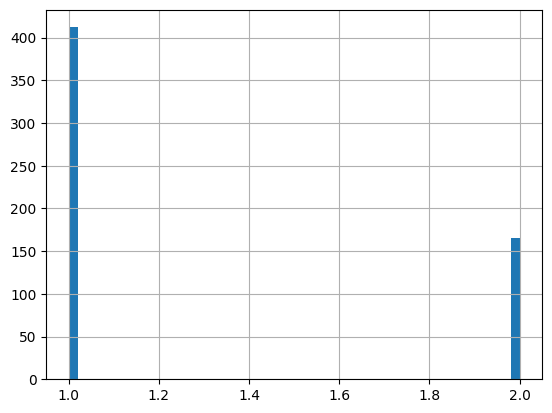

In [21]:
hist_df_outliers = df_outliers['Outcome'].hist(bins=50)

In [22]:
df_outliers

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,2,7.0,2.0,174.0,43.0,14,7.8,4.2,1.180,2,0,1
1,2,6.0,2.0,245.0,22.0,24,7.1,3.4,0.900,1,0,1
2,1,11.0,5.0,191.0,37.0,41,7.7,4.3,1.360,2,0,1
3,1,24.0,10.0,340.0,25.0,21,8.3,4.5,0.940,1,0,1
4,1,6.0,2.0,202.0,32.4,41,8.0,3.9,0.900,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
286,1,8.0,2.0,192.0,15.0,12,8.6,4.7,1.200,1,1,0
287,2,13.0,6.0,155.0,15.0,20,8.0,4.0,1.000,2,0,1
288,2,10.0,5.0,239.0,16.0,39,7.5,3.7,0.842,1,1,0
289,2,45.0,23.0,315.0,120.0,105,7.0,4.0,0.874,1,0,1


In [23]:
def get_majority_class_df(df,column):
    df_majority = df[df[column] == 1]
    return df_majority

def get_minority_class_df(df,column):
    df_minority = df[df[column] == 2]
    return df_minority


def oversampling(df):
    df_minority = get_minority_class_df(df,'Outcome')
    df_majority = get_majority_class_df(df,'Outcome')
    df_minority_oversampled = resample(df_minority, 
                                       replace=True,    
                                       n_samples=len(df_majority),     
                                       random_state=42) 
    df_oversampled = pd.concat([df_majority, df_minority_oversampled])
    return df_oversampled


def smote(df):
    X = df.drop('Outcome', axis=1)  
    y = df['Outcome']  
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X, y)
    df_smote = pd.concat([pd.DataFrame(X_smote, columns=X.columns), pd.DataFrame(y_smote, columns=['Outcome'])], axis=1)
    return df_smote

df_over = oversampling(df_outliers)
df_smote = smote(df_outliers)

df_smote

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Gender_Female,Gender_Male,Outcome
0,2,7.000000,2.000000,174.000000,43.000000,14,7.800000,4.200000,1.180000,0,1,2
1,2,6.000000,2.000000,245.000000,22.000000,24,7.100000,3.400000,0.900000,0,1,1
2,1,11.000000,5.000000,191.000000,37.000000,41,7.700000,4.300000,1.360000,0,1,2
3,1,24.000000,10.000000,340.000000,25.000000,21,8.300000,4.500000,0.940000,0,1,1
4,1,6.000000,2.000000,202.000000,32.400000,41,8.000000,3.900000,0.900000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
819,1,6.627982,1.627982,175.116054,40.767891,19,7.465184,4.162798,1.261844,0,1,2
820,1,9.329239,2.776413,220.695328,20.329239,24,6.964619,3.975185,1.332310,0,0,2
821,2,7.340804,2.000000,211.408035,38.723804,29,4.804482,2.236321,0.886816,0,0,2
822,0,5.069243,1.000000,349.784234,28.000000,51,7.851530,4.158454,1.093076,0,1,2


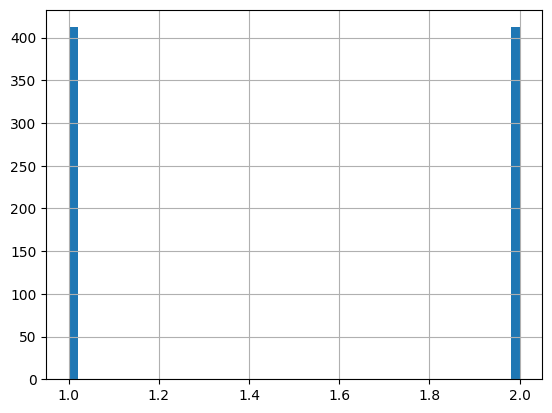

In [24]:
hist_df_smote = df_smote['Outcome'].hist(bins=50)

## **Qualité des données après complétion des données manquantes et gestion du déséquilibre de classe (SMOTE) :** 

In [25]:
def compare_stats(df1, df2):
    stats_diff = pd.DataFrame(index=df1.columns, columns=['Mean_Diff', 'Std_Diff'])
    
    stats_diff['Mean_Diff'] = ((df2.mean() - df1.mean()) / df1.mean()).abs()
    stats_diff['Std_Diff'] = ((df2.std() - df1.std()) / df1.std()).abs()
    
    return stats_diff

df_stats_comp_after_completion = compare_stats(df_imputed, df_smote)

# on remarque de gros écarts entre les deux dataframes... (ce qui n'est pas trop bon signe pour la qualité de notre Gestion du déséquilibre des classes)
df_stats_comp_after_completion

,Mean_Diff,Std_Diff
Age,0.085564,0.008013
Total_Bilirubin,0.274027,0.199578
Direct_Bilirubin,0.307957,0.213903
Alkaline_Phosphotase,0.106398,0.170804
Alamine_Aminotransferase,0.228506,0.248480
Aspartate_Aminotransferase,0.291404,0.411023
Total_Proteins,0.005142,0.073022
Albumin,0.027584,0.065022
Albumin_and_Globulin_Ratio,0.036631,0.104939
Outcome,0.171751,0.113154


In [26]:
print(df_imputed['Gender_Female'].value_counts())
print(df_imputed['Gender_Male'].value_counts())

print(df_smote['Gender_Female'].value_counts())
print(df_smote['Gender_Male'].value_counts())

# remarque: la méthode SMOTE a généré des personnes qui ont 0 et 0 ou 1 et 1 dans les colonnes Gender_Female, Gender_Male.



Gender_Female
0    448
1    141
Name: count, dtype: int64
Gender_Male
1    448
0    141
Name: count, dtype: int64
Gender_Female
0    654
1    170
Name: count, dtype: int64
Gender_Male
1    574
0    250
Name: count, dtype: int64


## **Qualité des données après complétion des données manquantes et gestion du déséquilibre de classe (Oversampling) :** 

In [27]:
def compare_stats(df1, df2):
    stats_diff = pd.DataFrame(index=df1.columns, columns=['Mean_Diff', 'Std_Diff'])
    
    stats_diff['Mean_Diff'] = ((df2.mean() - df1.mean()) / df1.mean()).abs()
    stats_diff['Std_Diff'] = ((df2.std() - df1.std()) / df1.std()).abs()
    
    return stats_diff

df_stats_comp_after_completion = compare_stats(df_imputed, df_over)

# on remarque également de gros écarts entre les deux dataframes... (ce qui n'est pas trop bon signe pour la qualité de notre Gestion du déséquilibre des classes)
# on va rester sur la méthode smote car c'est celle que l'on avait prise pour l'atelier2.
df_stats_comp_after_completion

,Mean_Diff,Std_Diff
Age,0.030469,0.044861
Total_Bilirubin,0.251319,0.197122
Direct_Bilirubin,0.282934,0.210464
Alkaline_Phosphotase,0.092612,0.157823
Alamine_Aminotransferase,0.211028,0.246078
Aspartate_Aminotransferase,0.258505,0.408472
Total_Proteins,0.000886,0.012103
Albumin,0.021661,0.025275
Albumin_and_Globulin_Ratio,0.030409,0.014070
Outcome,0.171751,0.113154


In [28]:
print(df_imputed['Gender_Female'].value_counts())
print(df_imputed['Gender_Male'].value_counts())

print(df_over['Gender_Female'].value_counts())
print(df_over['Gender_Male'].value_counts())

print(df_smote['Gender_Female'].value_counts())
print(df_smote['Gender_Male'].value_counts())

Gender_Female
0    448
1    141
Name: count, dtype: int64
Gender_Male
1    448
0    141
Name: count, dtype: int64
Gender_Female
0    604
1    220
Name: count, dtype: int64
Gender_Male
1    604
0    220
Name: count, dtype: int64
Gender_Female
0    654
1    170
Name: count, dtype: int64
Gender_Male
1    574
0    250
Name: count, dtype: int64


## **Biais de représentation des classes dans les groupes de données :**

In [29]:
print(df_smote.groupby('Gender_Female')['Outcome'].value_counts(normalize=True))


print(df_smote.groupby('Gender_Male')['Outcome'].value_counts(normalize=True))

#il va y avoir un biais dans les données, mais malheureusement, on ne peut pas faire grand chose pour l'éviter car on a déjà fait une complétion des données par rapport à l'outcome.

Gender_Female  Outcome
0              2          0.506116
               1          0.493884
1              1          0.523529
               2          0.476471
Name: proportion, dtype: float64
Gender_Male  Outcome
0            2          0.644000
             1          0.356000
1            1          0.562718
             2          0.437282
Name: proportion, dtype: float64


## **Normalisation des Données :**

**pour faire cela, on a décidé de faire passer l'outcome de 1 ou 2 à 0 ou 1 soit :** 

In [30]:
df_smote['Outcome'] = df_smote['Outcome'] - 1

In [31]:
from sklearn.preprocessing import MinMaxScaler

def min_max_scaling(df):
    minMaxScaler = MinMaxScaler()
    colonneOutcome = df['Outcome']
    autresColonnes = df.drop(columns=['Outcome'])

    autresColonnesNorm = minMaxScaler.fit_transform(autresColonnes)
    df_normalized = pd.DataFrame(autresColonnesNorm, columns=autresColonnes.columns)
    df_normalized['Outcome'] = colonneOutcome
    return df_normalized

df_normalized = min_max_scaling(df_smote)
df_normalized


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Gender_Female,Gender_Male,Outcome
0,0.50,0.004021,0.005102,0.054226,0.016583,0.001362,0.739130,0.717391,0.535484,0.0,1.0,1
1,0.50,0.002681,0.005102,0.088911,0.006030,0.004768,0.637681,0.543478,0.354839,0.0,1.0,0
2,0.25,0.009383,0.020408,0.062531,0.013568,0.010559,0.724638,0.739130,0.651613,0.0,1.0,1
3,0.25,0.026810,0.045918,0.135320,0.007538,0.003747,0.811594,0.782609,0.380645,0.0,1.0,0
4,0.25,0.002681,0.005102,0.067904,0.011256,0.010559,0.768116,0.652174,0.354839,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
819,0.25,0.003523,0.003204,0.054771,0.015461,0.003065,0.690606,0.709304,0.588286,0.0,1.0,1
820,0.25,0.007144,0.009063,0.077037,0.005191,0.004768,0.618061,0.668518,0.633748,0.0,0.0,1
821,0.50,0.004478,0.005102,0.072500,0.014434,0.006471,0.304997,0.290505,0.346333,0.0,0.0,1
822,0.00,0.001433,0.000000,0.140100,0.009045,0.013965,0.746599,0.708360,0.479404,0.0,1.0,1


In [32]:
from sklearn.preprocessing import StandardScaler

def standardisation(df):
    scaler = StandardScaler()
    
    outcome = df['Outcome']
    features = df.drop(columns=['Outcome'])
    
    features_standardized = scaler.fit_transform(features)
    
    df_standardized = pd.DataFrame(features_standardized, columns=features.columns)
    
    df_standardized['Outcome'] = outcome
    
    return df_standardized

df_standardized = standardisation(df_smote)
df_standardized


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Gender_Female,Gender_Male,Outcome
0,0.524530,-0.339072,-0.373478,-0.426534,-0.135633,-0.375977,1.264571,1.306499,0.779415,-0.509842,0.659955,1
1,0.524530,-0.358829,-0.373478,-0.082842,-0.306452,-0.316938,0.569577,0.233377,-0.271830,-0.509842,0.659955,0
2,-0.643612,-0.260042,-0.240181,-0.344242,-0.184438,-0.216573,1.165286,1.440639,1.455215,-0.509842,0.659955,1
3,-0.643612,-0.003195,-0.018020,0.377027,-0.282049,-0.334650,1.760996,1.708919,-0.121653,-0.509842,0.659955,0
4,-0.643612,-0.358829,-0.373478,-0.290994,-0.221856,-0.216573,1.463141,0.904078,-0.271830,-0.509842,0.659955,0
...,...,...,...,...,...,...,...,...,...,...,...,...
819,-0.643612,-0.346422,-0.390008,-0.421131,-0.153790,-0.346457,0.932149,1.256596,1.086694,-0.509842,0.659955,1
820,-0.643612,-0.293052,-0.338980,-0.200495,-0.320042,-0.316938,0.435164,1.004931,1.351254,-0.509842,-1.515256,1
821,0.524530,-0.332338,-0.373478,-0.245452,-0.170417,-0.287419,-1.709526,-1.327583,-0.321329,-0.509842,-1.515256,1
822,-1.811755,-0.377218,-0.417910,0.424389,-0.257647,-0.157534,1.315733,1.250770,0.453062,-0.509842,0.659955,1


## **Visualisation des Corrélations :**

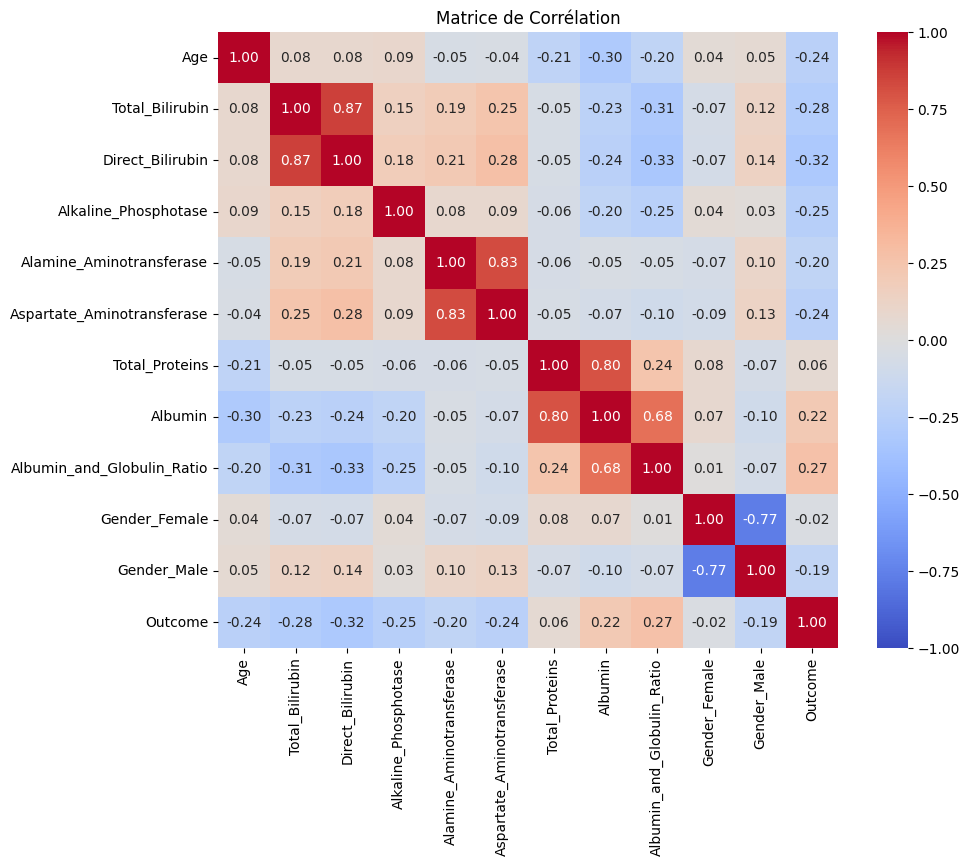

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_normalized.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de Corrélation')
plt.show()

## **Sélection de Features sur Base de la Matrice de Corrélation :**

j'avais fait ce prompt pour l'atelier2 : Écris une fonction en Python pour sélectionner les colonnes les plus corrélées avec la variable cible dans un DataFrame standardisé. Trie les corrélations par ordre décroissant, filtre les colonnes ayant une corrélation absolue supérieure à 0.2, et retourne un nouveau DataFrame contenant uniquement ces colonnes.

In [34]:
def select_features(df):
    # 1. Calcule la corrélation absolue avec 'Outcome' et trie les résultats
    corr_target = df_standardized.corr()['Outcome'].abs().sort_values(ascending=False)
    
    # 2. Sélectionne les features ayant une corrélation > 0.2
    selected_features = corr_target[corr_target > 0.2].index.tolist()
    
    # 3. Affiche les features sélectionnées
    #print(selected_features)
    
    # 4. Retourne un nouveau DataFrame avec uniquement les features sélectionnées
    return df[selected_features]

select_features(df_standardized)

,Outcome,Direct_Bilirubin,Total_Bilirubin,Albumin_and_Globulin_Ratio,Alkaline_Phosphotase,Age,Aspartate_Aminotransferase,Albumin
0,1,-0.373478,-0.339072,0.779415,-0.426534,0.524530,-0.375977,1.306499
1,0,-0.373478,-0.358829,-0.271830,-0.082842,0.524530,-0.316938,0.233377
2,1,-0.240181,-0.260042,1.455215,-0.344242,-0.643612,-0.216573,1.440639
3,0,-0.018020,-0.003195,-0.121653,0.377027,-0.643612,-0.334650,1.708919
4,0,-0.373478,-0.358829,-0.271830,-0.290994,-0.643612,-0.216573,0.904078
...,...,...,...,...,...,...,...,...
819,1,-0.390008,-0.346422,1.086694,-0.421131,-0.643612,-0.346457,1.256596
820,1,-0.338980,-0.293052,1.351254,-0.200495,-0.643612,-0.316938,1.004931
821,1,-0.373478,-0.332338,-0.321329,-0.245452,0.524530,-0.287419,-1.327583
822,1,-0.417910,-0.377218,0.453062,0.424389,-1.811755,-0.157534,1.250770


## **Sauvegarde du nouveau fichier formatté :**

In [35]:
select_features(df_standardized).to_csv('CABANES_DECHENAIS-PROJET.csv', index=False)